## Load Data

In [8]:
import pandas as pd

dataset = pd.read_csv('/kaggle/input/datasets/raihanmaulana/reviews-data/Reviews.csv')
dataset.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [10]:
dataset = dataset.dropna()

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 568401 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568401 non-null  int64 
 1   ProductId               568401 non-null  object
 2   UserId                  568401 non-null  object
 3   ProfileName             568401 non-null  object
 4   HelpfulnessNumerator    568401 non-null  int64 
 5   HelpfulnessDenominator  568401 non-null  int64 
 6   Score                   568401 non-null  int64 
 7   Time                    568401 non-null  int64 
 8   Summary                 568401 non-null  object
 9   Text                    568401 non-null  object
dtypes: int64(5), object(5)
memory usage: 47.7+ MB


## Turn Score Range into Sentiment

In [11]:
## drop row with score = 3
dataset = dataset[dataset['Score'] != 3]

## turn score into label
mapping = {
    1: 'Negative',
    2: 'Negative',
    4: 'Positive',
    5: 'Positive'
}

dataset['Sentiment'] = dataset['Score'].map(mapping)

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525763 entries, 0 to 568453
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      525763 non-null  int64 
 1   ProductId               525763 non-null  object
 2   UserId                  525763 non-null  object
 3   ProfileName             525763 non-null  object
 4   HelpfulnessNumerator    525763 non-null  int64 
 5   HelpfulnessDenominator  525763 non-null  int64 
 6   Score                   525763 non-null  int64 
 7   Time                    525763 non-null  int64 
 8   Summary                 525763 non-null  object
 9   Text                    525763 non-null  object
 10  Sentiment               525763 non-null  object
dtypes: int64(5), object(6)
memory usage: 48.1+ MB


In [12]:
dataset['Sentiment'][0]

'Positive'

## Preprocessing Review Text

In [13]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
import re
import html


## Cleaning Text

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 0. Decode HTML entities (misal &amp; -> &) lalu hapus tag HTML (misal <br />)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Delete number
    text = re.sub(r'\d+', '', text)
    
    # 3. Delete punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Tokenization
    tokens = word_tokenize(text)
    
    # 5. Delete stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 6. Gabungkan kembali menjadi teks
    return ' '.join(tokens)


dataset['clean_text'] = dataset['Text'].apply(clean_text)

dataset['clean_text'][0]

'bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better'

## Split Data

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X = dataset['clean_text']
y = dataset['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


tfidf = TfidfVectorizer()


X_train_tfidf = tfidf.fit_transform(X_train)


X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (420610, 166845)
Testing shape: (105153, 166845)


## Train TF-IDF + Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)


model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)

print("Model berhasil dilatih.")

Model berhasil dilatih.


In [17]:
from sklearn.metrics import classification_report


y_pred = model.predict(X_test_tfidf)


print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))


report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("\nNegative Class:")
print("Precision:", report['Negative']['precision'])
print("Recall   :", report['Negative']['recall'])
print("F1-score :", report['Negative']['f1-score'])

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.91      0.76     16401
    Positive       0.98      0.91      0.95     88752

    accuracy                           0.91    105153
   macro avg       0.82      0.91      0.85    105153
weighted avg       0.93      0.91      0.92    105153


Negative Class:
Precision: 0.6559570441441838
Recall   : 0.9087250777391622
F1-score : 0.7619242370021982


## Train NEURAL NETWORK - EMBEDDING + LSTM

In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [19]:
y_train_nn = y_train.map({
    'Negative': 0,
    'Positive': 1
})

y_test_nn = y_test.map({
    'Negative': 0,
    'Positive': 1
})

print(y_train_nn.value_counts())
print(y_test_nn.value_counts())

Sentiment
1    355004
0     65606
Name: count, dtype: int64
Sentiment
1    88752
0    16401
Name: count, dtype: int64


In [20]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

# Fit tokenizer hanya pada training data
tokenizer.fit_on_texts(X_train)

# Ubah teks menjadi sequence angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[:2])

[[157, 962, 396, 2717, 168, 5128, 396, 85, 27, 1, 22, 4681, 1222, 396, 2717, 3, 1294, 44, 81, 10, 11], [5, 755, 386, 1, 106, 263, 1386, 346, 1, 1362, 47, 1136, 25, 1140]]


In [21]:
max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", X_train_pad.shape)
print("Testing shape :", X_test_pad.shape)

Training shape: (420610, 100)
Testing shape : (105153, 100)


In [22]:
vocab_size = min(
    10000,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size:", vocab_size)

Vocabulary size: 10000


In [23]:
model_nn = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

I0000 00:00:1791253351.040604      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791253351.044481      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [24]:
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
classes = np.unique(y_train_nn)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_nn
)

class_weights = dict(
    zip(classes, weights)
)

print("Class weights:")
print(class_weights)

Class weights:
{np.int64(0): np.float64(3.2055757095387616), np.int64(1): np.float64(0.5924017757546394)}


In [26]:
history = model_nn.fit(
    X_train_pad,
    y_train_nn,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 113s 10ms/step - accuracy: 0.6835 - loss: 0.5103 - val_accuracy: 0.9106 - val_loss: 0.2254
Epoch 2/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 107s 10ms/step - accuracy: 0.9119 - loss: 0.2286 - val_accuracy: 0.9153 - val_loss: 0.2142
Epoch 3/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 107s 10ms/step - accuracy: 0.9331 - loss: 0.1771 - val_accuracy: 0.9278 - val_loss: 0.1904
Epoch 4/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 106s 10ms/step - accuracy: 0.9459 - loss: 0.1429 - val_accuracy: 0.9038 - val_loss: 0.2598
Epoch 5/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 104s 10ms/step - accuracy: 0.9555 - loss: 0.1178 - val_accuracy: 0.9239 - val_loss: 0.2229
Epoch 6/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 100s 9ms/step - accuracy: 0.9626 - loss: 0.0986 - val_accuracy: 0.9340 - val_loss: 0.2107
Epoch 7/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 96s 9ms/step - accuracy: 0.9694 - loss: 0.0819 - val_accuracy: 0.9281 - val_loss: 0.2288
Epoch 8/10
10516/10516 ━━━━━━━━━━━━━━━━━━━━ 95s 9ms/step -

In [27]:
y_pred_prob_nn = model_nn.predict(X_test_pad)

y_pred_nn = (
    y_pred_prob_nn >= 0.5
).astype(int).flatten()

print("Actual    :", y_test_nn.values[:10])
print("Predicted :", y_pred_nn[:10])

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
Actual    : [1 1 1 1 1 1 0 0 1 1]
Predicted : [1 1 1 1 0 1 0 0 1 1]


In [28]:
print("Neural Network Classification Report:")

print(
    classification_report(
        y_test_nn,
        y_pred_nn,
        target_names=['Negative', 'Positive']
    )
)

Neural Network Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.92      0.76     16401
    Positive       0.98      0.91      0.95     88752

    accuracy                           0.91    105153
   macro avg       0.82      0.91      0.85    105153
weighted avg       0.93      0.91      0.92    105153



In [29]:
report_nn = classification_report(
    y_test_nn,
    y_pred_nn,
    output_dict=True
)

print("Negative Precision:",
      report_nn['0']['precision'])

print("Negative Recall:",
      report_nn['0']['recall'])

print("Negative F1-score:",
      report_nn['0']['f1-score'])

Negative Precision: 0.6521814404432132
Negative Recall: 0.9187244680202427
Negative F1-score: 0.7628401468168586


## Analyze Bad Review Frequent

In [30]:
from collections import Counter
import matplotlib.pyplot as plt

In [31]:
negative_reviews = dataset[
    dataset['Sentiment'] == 'Negative'
].copy()

print("Jumlah review negatif:", len(negative_reviews))

Jumlah review negatif: 82007


In [32]:
all_negative_text = ' '.join(
    negative_reviews['clean_text'].dropna()
)

In [33]:
word_counts = Counter(
    all_negative_text.split()
)

top_words = word_counts.most_common(30)

print(top_words)

[('like', 43814), ('product', 32202), ('taste', 31416), ('one', 27618), ('would', 26788), ('food', 22413), ('coffee', 22189), ('good', 21386), ('flavor', 20120), ('dont', 17530), ('even', 16342), ('get', 16057), ('tea', 16006), ('buy', 14967), ('really', 14430), ('much', 13935), ('amazon', 13349), ('tried', 12009), ('im', 11946), ('first', 11827), ('box', 11740), ('time', 11465), ('dog', 11383), ('bought', 11176), ('eat', 10655), ('made', 10475), ('bad', 10357), ('also', 10243), ('better', 10241), ('try', 10200)]


In [34]:
top_words_df = pd.DataFrame(
    top_words,
    columns=['word', 'frequency']
)

print(top_words_df)

       word  frequency
0      like      43814
1   product      32202
2     taste      31416
3       one      27618
4     would      26788
5      food      22413
6    coffee      22189
7      good      21386
8    flavor      20120
9      dont      17530
10     even      16342
11      get      16057
12      tea      16006
13      buy      14967
14   really      14430
15     much      13935
16   amazon      13349
17    tried      12009
18       im      11946
19    first      11827
20      box      11740
21     time      11465
22      dog      11383
23   bought      11176
24      eat      10655
25     made      10475
26      bad      10357
27     also      10243
28   better      10241
29      try      10200


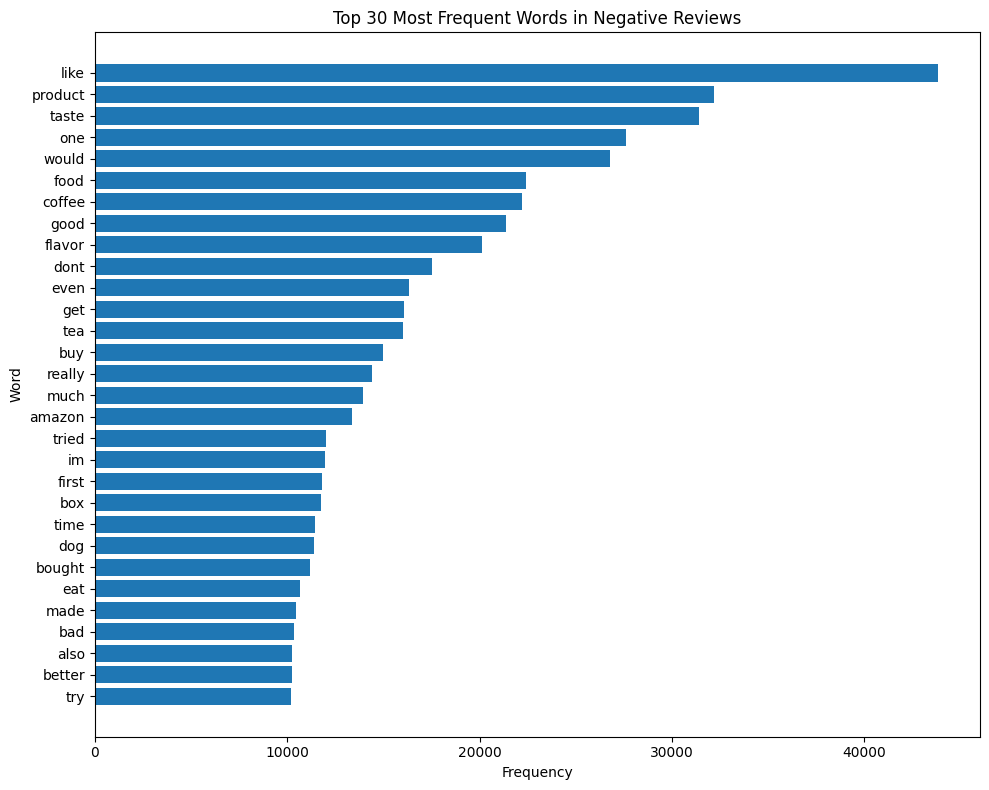

In [35]:
plt.figure(figsize=(10, 8))

plt.barh(
    top_words_df['word'][::-1],
    top_words_df['frequency'][::-1]
)

plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 30 Most Frequent Words in Negative Reviews')

plt.tight_layout()
plt.show()